<a href="https://colab.research.google.com/github/Sohilaayman129/-Daniels/blob/master/pattern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("/Work Productivity.csv")
df.head()

Saving Work Productivity.csv to Work Productivity.csv


,Employee_ID,Age,Gender,Country,Job_Role,Experience_Years,Company_Size,Work_Hours_Per_Day,Meetings_Per_Day,Internet_Speed_Mbps,Work_Environment,Sleep_Hours,Exercise_Hours_Per_Week,Screen_Time_Hours,Stress_Level,Productivity_Score,Burnout_Risk
0,1,50,Other,South Korea,Software Developer,14,Large,8.4,4,123.4,Hybrid,6.2,0.6,9.1,Low,75,No
1,2,45,Female,India,Software Developer,2,Small,4.1,1,147.2,Office,8.7,0.0,13.9,Medium,76,No
2,3,33,Female,Australia,HR,9,Medium,7.1,3,14.4,Office,6.6,2.4,5.4,Medium,69,No
3,4,37,Female,USA,HR,14,Large,6.7,6,127.5,Hybrid,5.9,5.9,9.2,High,82,No
4,5,28,Other,UK,Data Analyst,4,Small,6.7,1,190.3,Home,8.8,4.9,7.7,High,100,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              30000 non-null  int64  
 1   Age                      30000 non-null  int64  
 2   Gender                   30000 non-null  object 
 3   Country                  30000 non-null  object 
 4   Job_Role                 30000 non-null  object 
 5   Experience_Years         30000 non-null  int64  
 6   Company_Size             30000 non-null  object 
 7   Work_Hours_Per_Day       30000 non-null  float64
 8   Meetings_Per_Day         30000 non-null  int64  
 9   Internet_Speed_Mbps      30000 non-null  float64
 10  Work_Environment         30000 non-null  object 
 11  Sleep_Hours              30000 non-null  float64
 12  Exercise_Hours_Per_Week  30000 non-null  float64
 13  Screen_Time_Hours        30000 non-null  float64
 14  Stress_Level          

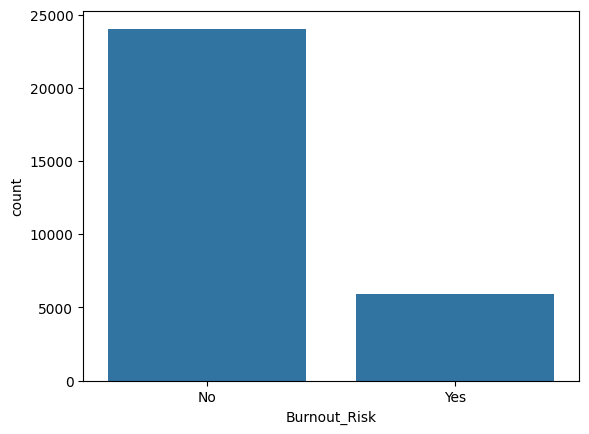

In [7]:
sns.countplot(x='Burnout_Risk', data=df)
plt.show()

In [8]:
df['Burnout_Risk'] = df['Burnout_Risk'].map({'Yes':1, 'No':0})

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              30000 non-null  int64  
 1   Age                      30000 non-null  int64  
 2   Gender                   30000 non-null  object 
 3   Country                  30000 non-null  object 
 4   Job_Role                 30000 non-null  object 
 5   Experience_Years         30000 non-null  int64  
 6   Company_Size             30000 non-null  object 
 7   Work_Hours_Per_Day       30000 non-null  float64
 8   Meetings_Per_Day         30000 non-null  int64  
 9   Internet_Speed_Mbps      30000 non-null  float64
 10  Work_Environment         30000 non-null  object 
 11  Sleep_Hours              30000 non-null  float64
 12  Exercise_Hours_Per_Week  30000 non-null  float64
 13  Screen_Time_Hours        30000 non-null  float64
 14  Stress_Level          

In [10]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              30000 non-null  int64  
 1   Age                      30000 non-null  int64  
 2   Gender                   30000 non-null  int64  
 3   Country                  30000 non-null  int64  
 4   Job_Role                 30000 non-null  int64  
 5   Experience_Years         30000 non-null  int64  
 6   Company_Size             30000 non-null  int64  
 7   Work_Hours_Per_Day       30000 non-null  float64
 8   Meetings_Per_Day         30000 non-null  int64  
 9   Internet_Speed_Mbps      30000 non-null  float64
 10  Work_Environment         30000 non-null  int64  
 11  Sleep_Hours              30000 non-null  float64
 12  Exercise_Hours_Per_Week  30000 non-null  float64
 13  Screen_Time_Hours        30000 non-null  float64
 14  Stress_Level          

In [12]:
X = df.drop(['Burnout_Risk', 'Productivity_Score'], axis=1)
y = df['Burnout_Risk']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, y_pred))

LR Accuracy: 0.9456666666666667


              precision    recall  f1-score   support

           0       0.96      0.97      0.97      4809
           1       0.88      0.85      0.86      1191

    accuracy                           0.95      6000
   macro avg       0.92      0.91      0.91      6000
weighted avg       0.95      0.95      0.95      6000



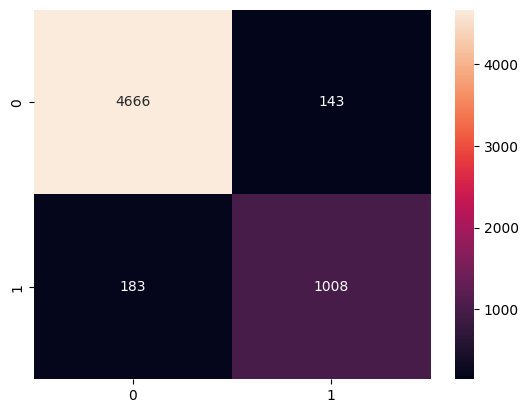

In [20]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()